In [144]:
using LinearAlgebra
using Distributions
using Plots
using LaTeXStrings
using Printf
using FileIO
import JLD2
using CairoMakie 
using MeasureBase
using Revise

In [145]:
using Newtrinos

In [146]:
osc_cfg_NNM = Newtrinos.osc.OscillationConfig(
    #flavour = Newtrinos.osc.NND(three_flavour=Newtrinos.osc.ThreeFlavour(ordering=:NO)),
    flavour=Newtrinos.osc.ThreeFlavour(ordering=:NO),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction = Newtrinos.osc.SI(),
    )

osc = Newtrinos.osc.configure(osc_cfg_NNM)
atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()
xsec = Newtrinos.xsec.configure()

physics_NNM = (; osc, atm_flux, earth_layers, xsec);

In [147]:
experiments_NNM = (;
    juno = Newtrinos.juno.configure(physics_NNM)
);

[ Info: Loading juno data


In [148]:
p_NNM = Newtrinos.get_params(experiments_NNM)

(juno_accidental_norm = 1.0, juno_atmnc_norm = 1.0, juno_co_norm = 1.0, juno_detection_epsilon = 1.0, juno_fast_neutron_norm = 1.0, juno_geo_rate_norm = 1.0, juno_geo_shape_eps = 0.0, juno_lihe_norm = 1.0, juno_res_a = 0.0261, juno_res_b = 0.0082, juno_res_c = 0.0123, juno_world_reactor_norm = 1.0, junotao_energy_scale = 1.0, junotao_flux_scale = 1.0, junotao_shape_eps = 0.0, m₀ = 0.1, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [149]:
params_NNM_new = (junotao_flux_scale = 1.0, junotao_energy_scale = 1.0, juno_detection_epsilon = 1.0, juno_res_a = 0.0261, junotao_shape_eps = 0.0, juno_geo_shape_eps = 0.0, juno_geo_rate_norm = 1.0, juno_accidental_norm = 1.0, juno_world_reactor_norm = 1.0, juno_lihe_norm = 1.0, juno_co_norm = 1.0, juno_atmnc_norm = 1.0, juno_fast_neutron_norm = 1.0, detection_epsilon = 1.0, m₀ = 0.01, η = 1.05, N = 50, r = 1, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

(junotao_flux_scale = 1.0, junotao_energy_scale = 1.0, juno_detection_epsilon = 1.0, juno_res_a = 0.0261, junotao_shape_eps = 0.0, juno_geo_shape_eps = 0.0, juno_geo_rate_norm = 1.0, juno_accidental_norm = 1.0, juno_world_reactor_norm = 1.0, juno_lihe_norm = 1.0, juno_co_norm = 1.0, juno_atmnc_norm = 1.0, juno_fast_neutron_norm = 1.0, detection_epsilon = 1.0, m₀ = 0.01, η = 1.05, N = 50, r = 1, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [150]:
pri_NNM = Newtrinos.get_priors(experiments_NNM)

(juno_accidental_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.01); lower=0.0, upper=Inf), juno_atmnc_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.5); lower=0.0, upper=Inf), juno_co_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.5); lower=0.0, upper=Inf), juno_detection_epsilon = Truncated(Normal{Float64}(μ=1.0, σ=0.01); lower=0.0, upper=Inf), juno_fast_neutron_norm = Truncated(Normal{Float64}(μ=1.0, σ=1.0); lower=0.0, upper=Inf), juno_geo_rate_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.3); lower=0.0, upper=Inf), juno_geo_shape_eps = Normal{Float64}(μ=0.0, σ=1.0), juno_lihe_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.2); lower=0.0, upper=Inf), juno_res_a = Truncated(Normal{Float64}(μ=0.0261, σ=0.0002); lower=0.0, upper=Inf), juno_res_b = Truncated(Normal{Float64}(μ=0.0082, σ=0.0001); lower=0.0, upper=Inf), juno_res_c = Truncated(Normal{Float64}(μ=0.0123, σ=0.0004); lower=0.0, upper=Inf), juno_world_reactor_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.02); lower=0.0, upper=Inf), junotao_energ

In [151]:
priors_NNM_new = (junotao_flux_scale = Truncated(Normal(1.0, 0.02), 0.0, Inf), junotao_energy_scale = Truncated(Normal(1.0, 0.005), 0.0, Inf), juno_detection_epsilon = Truncated(Normal(1.0, 0.01), 0.0, Inf), juno_res_a = Truncated(Normal(0.0261, 0.0002), 0.0, Inf), junotao_shape_eps = Normal(0,1), juno_geo_shape_eps = Normal(0,1), juno_geo_rate_norm = Truncated(Normal(1.0, 0.30), 0.0, Inf), juno_accidental_norm = Truncated(Normal(1.0, 0.01), 0.0, Inf), juno_world_reactor_norm = Truncated(Normal(1.0, 0.02), 0.0, Inf), juno_lihe_norm = Truncated(Normal(1.0, 0.20), 0.0, Inf), juno_co_norm = Truncated(Normal(1.0, 0.50), 0.0, Inf), juno_atmnc_norm = Truncated(Normal(1.0, 0.50), 0.0, Inf), juno_fast_neutron_norm = Truncated(Normal(1.0, 1.0), 0.0, Inf), detection_epsilon = Normal(1.0, 0.01), m₀ = LogUniform(1e-6, 0.05), η = Uniform(1.000000001, 1.1), N = DiscreteUniform(2, 40), r = Uniform(1e-8, 1), Δm²₂₁ = Uniform(6.5e-5, 9.0e-5), Δm²₃₁ = Uniform(0.002, 0.003), δCP = Uniform(0.0, 6.283185307179586), θ₁₂ = Uniform(0.4205343352839651, 0.7853981633974483), θ₁₃ = Uniform(0.1, 0.2), θ₂₃ = Uniform(0.5235987755982988, 1.0471975511965976))

(junotao_flux_scale = Truncated(Normal{Float64}(μ=1.0, σ=0.02); lower=0.0, upper=Inf), junotao_energy_scale = Truncated(Normal{Float64}(μ=1.0, σ=0.005); lower=0.0, upper=Inf), juno_detection_epsilon = Truncated(Normal{Float64}(μ=1.0, σ=0.01); lower=0.0, upper=Inf), juno_res_a = Truncated(Normal{Float64}(μ=0.0261, σ=0.0002); lower=0.0, upper=Inf), junotao_shape_eps = Normal{Float64}(μ=0.0, σ=1.0), juno_geo_shape_eps = Normal{Float64}(μ=0.0, σ=1.0), juno_geo_rate_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.3); lower=0.0, upper=Inf), juno_accidental_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.01); lower=0.0, upper=Inf), juno_world_reactor_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.02); lower=0.0, upper=Inf), juno_lihe_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.2); lower=0.0, upper=Inf), juno_co_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.5); lower=0.0, upper=Inf), juno_atmnc_norm = Truncated(Normal{Float64}(μ=1.0, σ=0.5); lower=0.0, upper=Inf), juno_fast_neutron_norm = Truncated(Normal{

In [152]:
a_NNM = Newtrinos.juno.get_assets(physics_NNM, 6.0);

[ Info: Loading juno data


In [153]:
E_vis_NNM = a_NNM.E_bins_visible
E_nu_NNM = a_NNM.visible_to_neutrino_interp.(E_vis_NNM .* p_NNM.junotao_energy_scale)
L_km_NNM = a_NNM.reactors.Baseline_m ./ 1e3
P_NNM = physics_NNM.osc.osc_prob(E_nu_NNM ./ 1e3, L_km_NNM, p_NNM; anti=true)
P_ee_NNM = P_NNM[:, :, 1, 1]
prob_weighted_NNM = vec(sum(P_ee_NNM .* a_NNM.reactors.Flux_Factor', dims=2))
pro_NNM = (P_ee = P_ee_NNM, prob_weighted_flat = prob_weighted_NNM)

(P_ee = [0.8712791561172093 0.8828533333604324 … 0.8741634754269146 0.2657116132516498; 0.8656604742176442 0.8463665028450298 … 0.7875779159834544 0.16649399214893412; … ; 0.7479976594157939 0.7464613170851406 … 0.7399460790420487 0.5232392661538525; 0.7466867939445636 0.7450034118710571 … 0.7381373051466997 0.526322548655099], prob_weighted_flat = [0.8535853987432908, 0.8090317678196166, 0.7705515553707126, 0.7934029961756683, 0.7605599942807806, 0.7118493192781604, 0.7277742444664539, 0.7256143788719355, 0.6755090102776983, 0.651931006679244  …  0.7429450670098386, 0.7424350999302157, 0.7418545996252764, 0.7412103149801392, 0.7404973806165731, 0.739701399722336, 0.7388015112879246, 0.7377740620392939, 0.7365964634941201, 0.7352508206248759])

In [154]:
using CSV
using DataFrames
df_j= CSV.read(joinpath("/home/sofialon/Newtrinos.jl/src/experiments/juno/juno_NO_observed.csv"),DataFrame)
observed_juno = df_j.Counts
lik_NNM = Newtrinos.generate_likelihood(experiments_NNM, observed_juno);

In [155]:
osc_cfg_SM = Newtrinos.osc.OscillationConfig(
    flavour =Newtrinos.osc.ThreeFlavour(ordering=:IO),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg_SM)
atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics_SM = (; osc)

experiments_SM = (;
    juno = Newtrinos.juno.configure(physics_SM)
)

p_SM = Newtrinos.get_params(experiments_SM)
pri_SM = Newtrinos.get_priors(experiments_SM)
a_SM = Newtrinos.juno.get_assets(physics_SM, 6.0)
E_vis_SM = a_SM.E_bins_visible
E_nu_SM = a_SM.visible_to_neutrino_interp.(E_vis_SM .* p_SM.junotao_energy_scale)
L_km_SM = a_SM.reactors.Baseline_m ./ 1e3
P_SM = physics_SM.osc.osc_prob(E_nu_SM ./ 1e3, L_km_SM, p_SM; anti=true)
P_ee_SM = P_SM[:, :, 1, 1]
prob_weighted_SM = vec(sum(P_ee_SM .* a_SM.reactors.Flux_Factor', dims=2))
pro_SM = (P_ee = P_ee_SM, prob_weighted_flat = prob_weighted_SM)
lik_SM = Newtrinos.generate_likelihood(experiments_SM, observed_juno);

[ Info: Loading juno data
[ Info: Loading juno data


┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


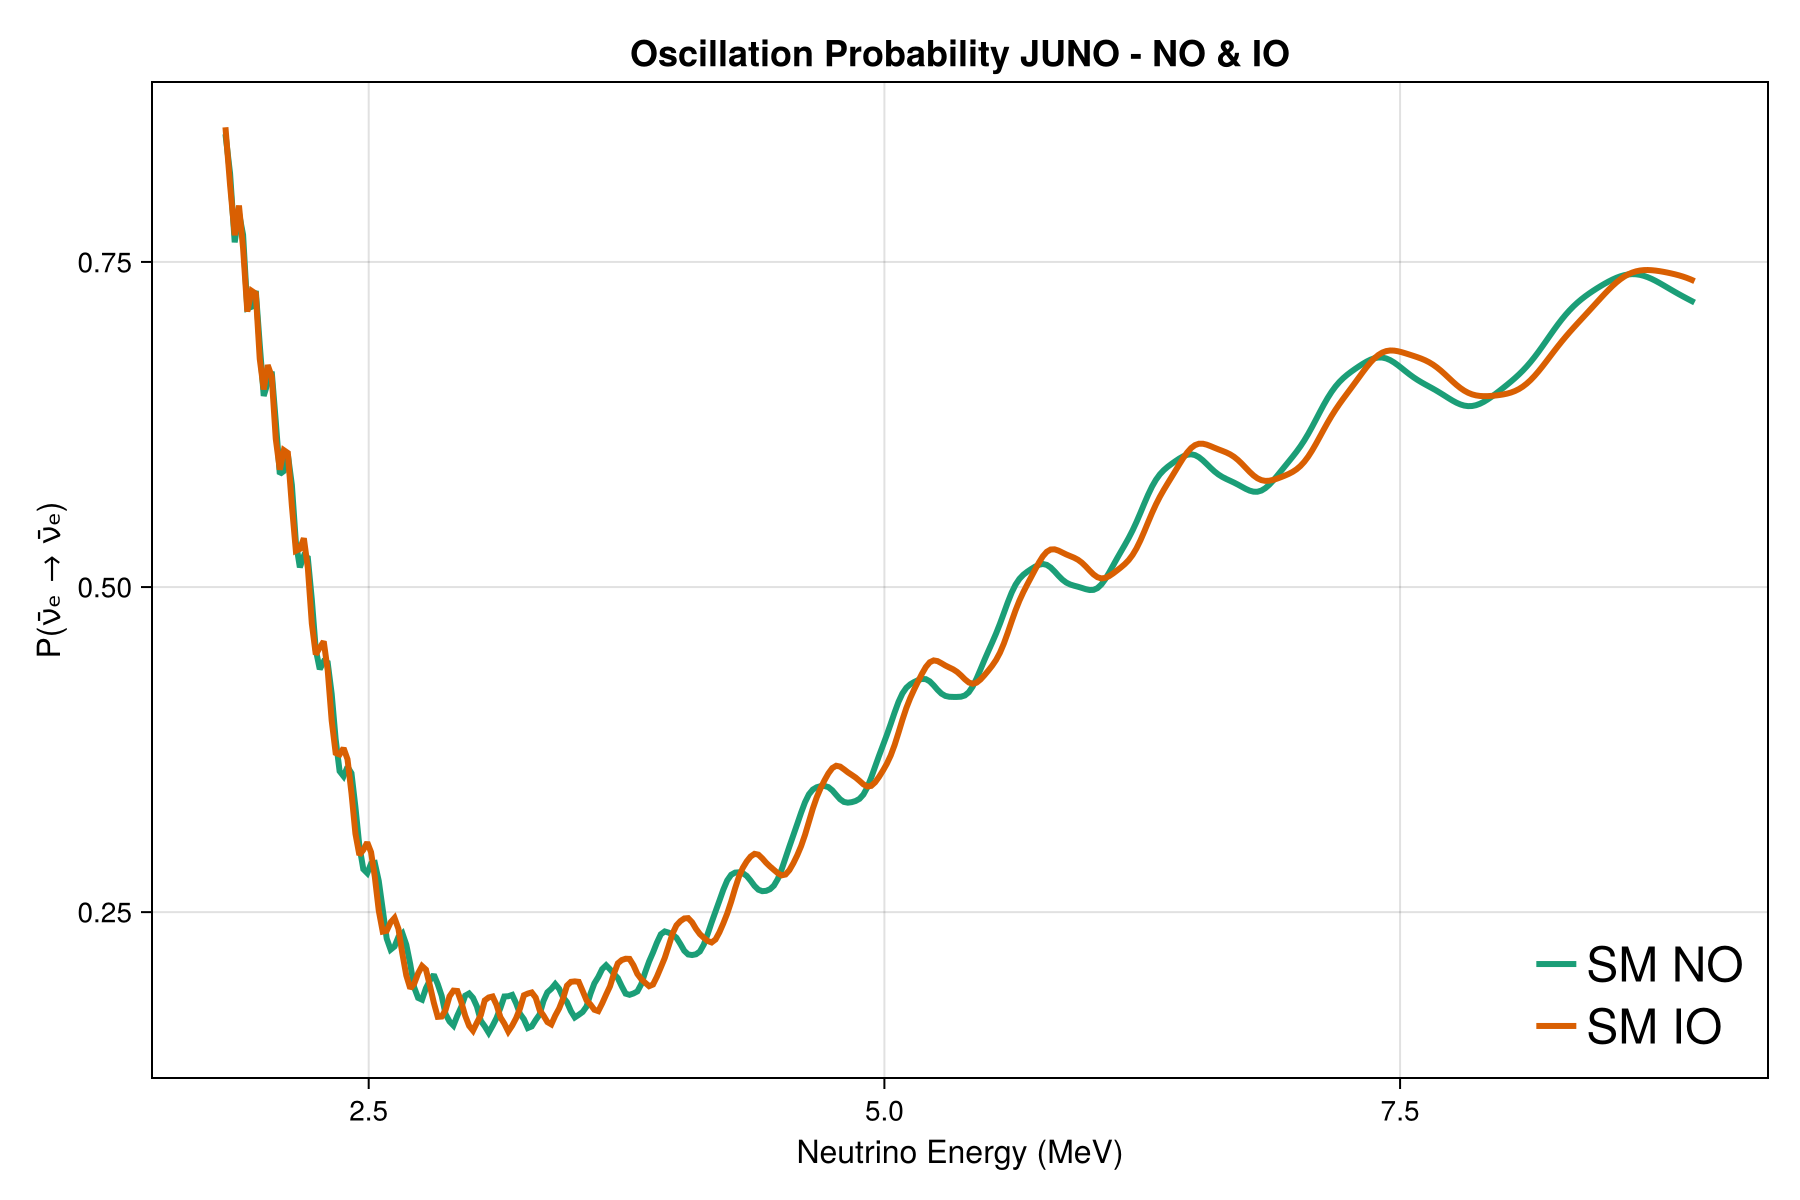

CairoMakie.Screen{SVG}


In [158]:
using CairoMakie
using ColorSchemes

palette = cgrad(:Dark2_8, categorical=true)

c_1 = palette[1]
c_2 = palette[2]

P_ee_NNM = pro_NNM.P_ee    
E_vis_NNM = a_NNM.E_bins_visible  
E_nu_NNM = a_NNM.visible_to_neutrino_interp.(E_vis_NNM .* p_NNM.junotao_energy_scale) 

P_ee_SM = pro_SM.P_ee   
E_vis_SM = a_SM.E_bins_visible  
E_nu_SM = a_SM.visible_to_neutrino_interp.(E_vis_SM .* p_SM.junotao_energy_scale)  

fig = Figure(resolution=(900, 600))

ax = Axis(
    fig[1, 1],
    xlabel = "Neutrino Energy (MeV)",
    ylabel = "P(ν̄ₑ → ν̄ₑ)",
    title = "Oscillation Probability JUNO - NO & IO",
    xticklabelsize = 14,
    yticklabelsize = 14,
    xlabelsize = 16,
    ylabelsize = 16,
    titlesize = 18
)

lines!(
    ax,
    E_nu_SM,
    pro_SM.prob_weighted_flat,
    color = c_1,
    linewidth = 3,
    label = "SM NO"
)

lines!(
    ax,
    E_nu_NNM,
    pro_NNM.prob_weighted_flat,
    color = c_2,
    linewidth = 3,
    label = "SM IO"
)

axislegend(
    ax,
    position = :rb,
    labelsize=24,
    framevisible = false
)



display("image/png", fig)

# Recommended for papers
save("/home/sofialon/Newtrinos.jl/plots_svg/juno/juno_NO_IO.png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/juno/juno_NO_IO.svg", fig)

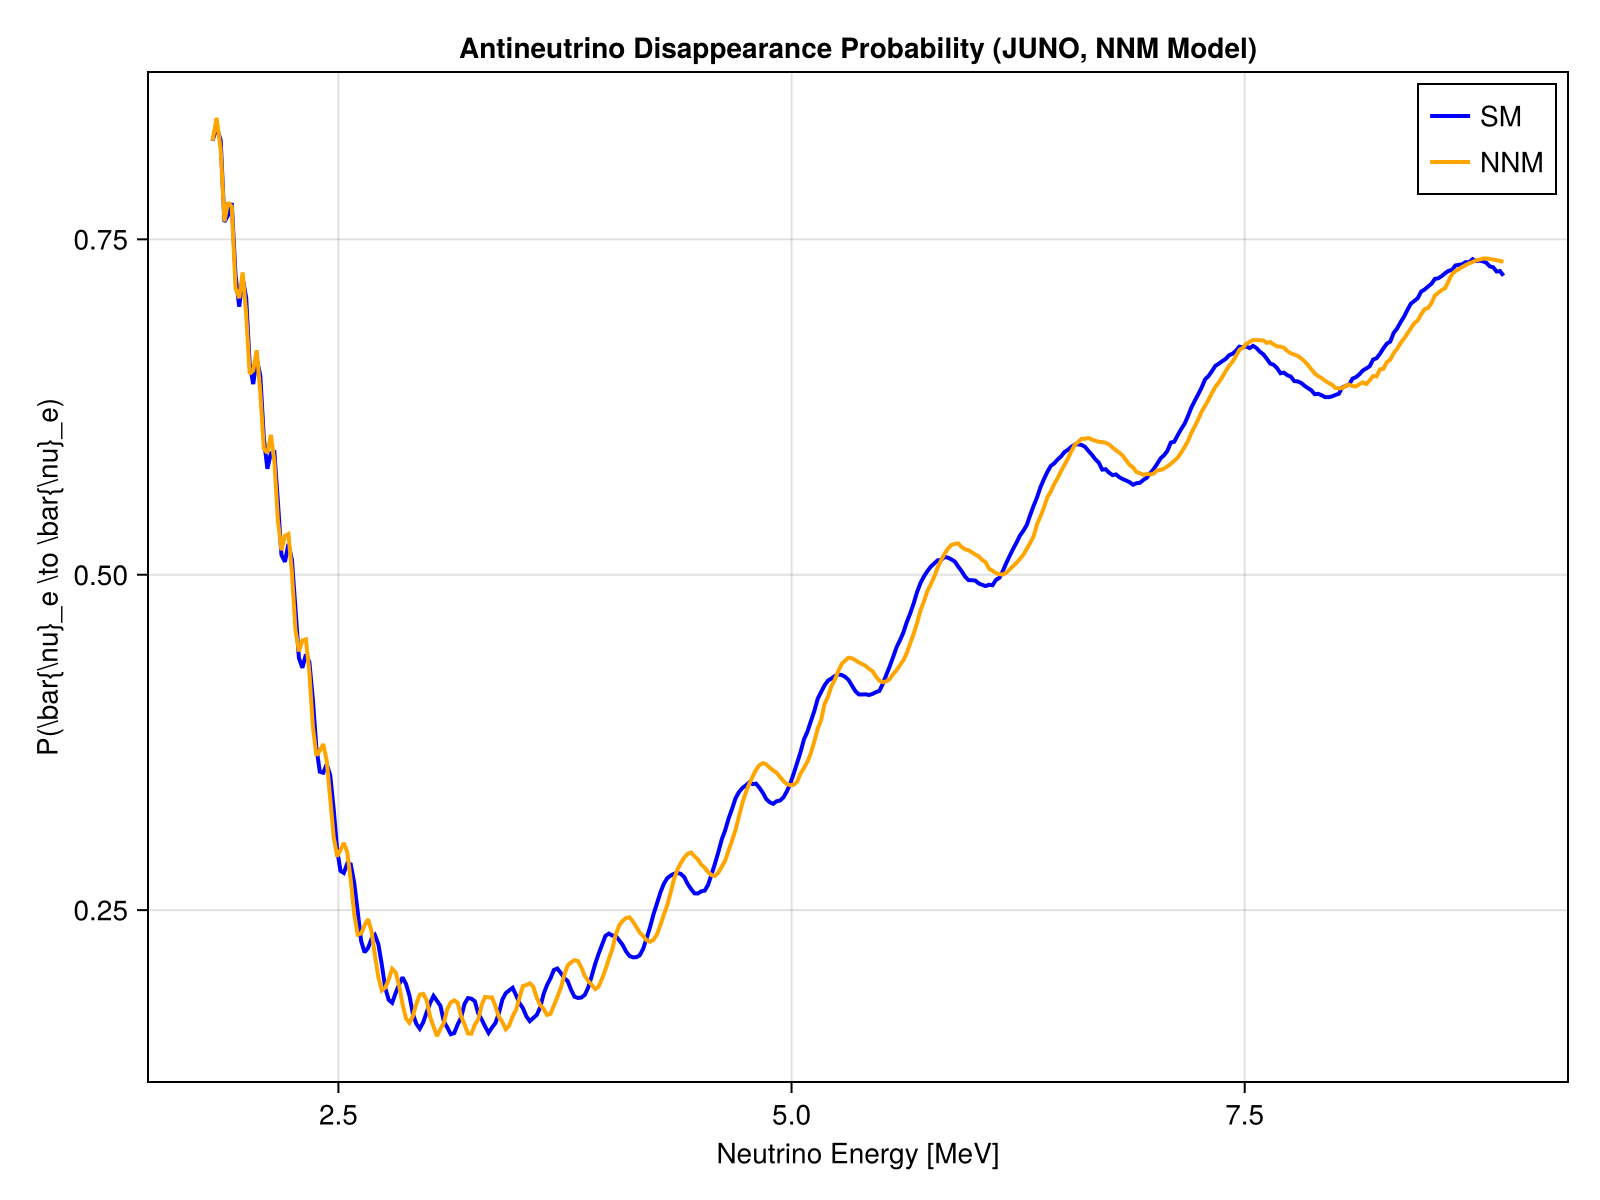

In [103]:
P_ee_NNM = pro_NNM.P_ee    

E_vis_NNM = a_NNM.E_bins_visible  

E_nu_NNM = a_NNM.visible_to_neutrino_interp.(E_vis_NNM .* p_NNM.junotao_energy_scale) 

P_ee_SM = pro_SM.P_ee   

E_vis_SM = a_SM.E_bins_visible  

E_nu_SM = a_SM.visible_to_neutrino_interp.(E_vis_SM .* p_SM.junotao_energy_scale)  

fig = Figure(size=(800, 600))
ax = Axis(fig[1, 1],
    xlabel="Neutrino Energy [MeV]",
    ylabel="P(\\bar{\\nu}_e \\to \\bar{\\nu}_e)",
    title="Antineutrino Disappearance Probability (JUNO, NNM Model)"
)

CairoMakie.lines!(ax, E_nu_SM, pro_SM.prob_weighted_flat, color=:blue, linewidth=2, label="SM")
CairoMakie.lines!(ax, E_nu_NNM, pro_NNM.prob_weighted_flat, color=:orange, linewidth=2, label="NNM")

axislegend(ax)
fig

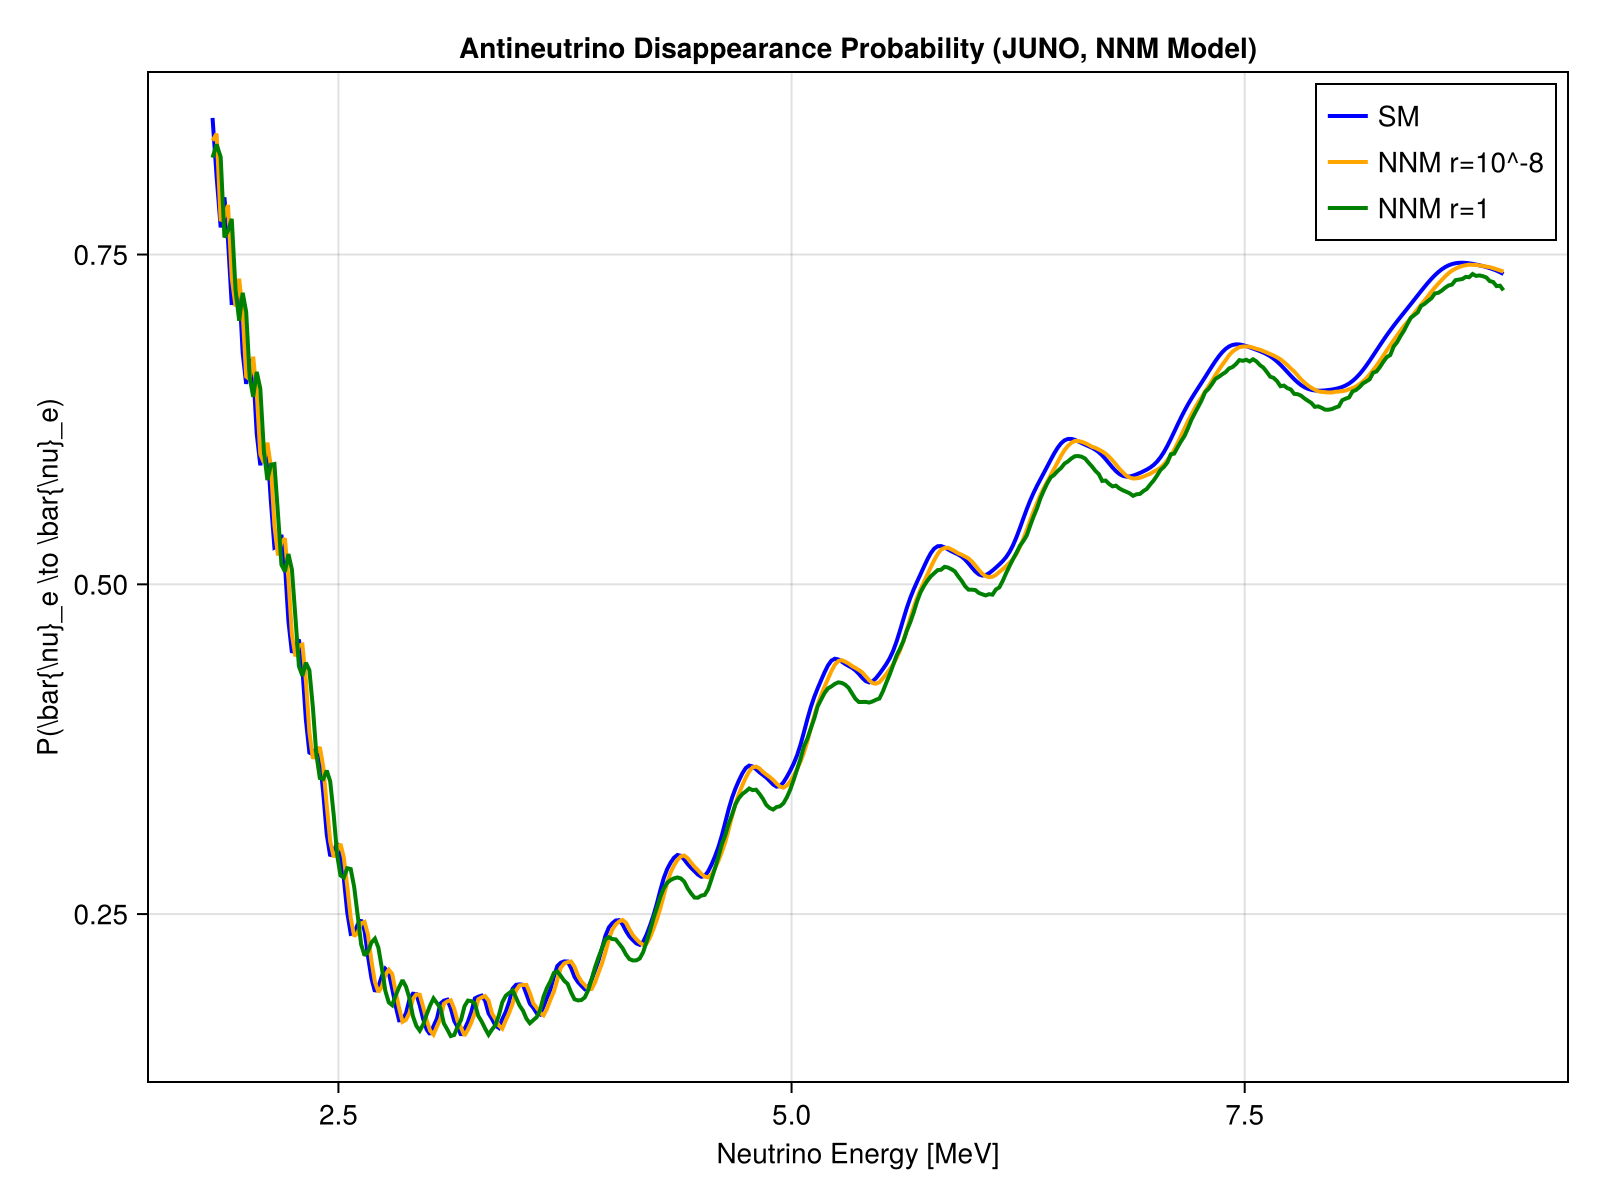

In [87]:
E_vis_NNM = a_NNM.E_bins_visible
E_nu_NNM = a_NNM.visible_to_neutrino_interp.(E_vis_NNM .* params_NNM_new.junotao_energy_scale)
L_km_NNM = a_NNM.reactors.Baseline_m ./ 1e3
P_NNM_lar = physics_NNM.osc.osc_prob(E_nu_NNM ./ 1e3, L_km_NNM, params_NNM_new; anti=true)
P_ee_NNM = P_NNM_lar[:, :, 1, 1]
prob_weighted_NNM_lar = vec(sum(P_ee_NNM .* a_NNM.reactors.Flux_Factor', dims=2))
pro_NNM_lar = (P_ee = P_ee_NNM, prob_weighted_flat = prob_weighted_NNM_lar)

E_vis_SM = a_SM.E_bins_visible
E_nu_SM = a_SM.visible_to_neutrino_interp.(E_vis_SM .* p_SM.junotao_energy_scale)

fig = Figure(size=(800, 600))
ax = Axis(fig[1, 1],
    xlabel="Neutrino Energy [MeV]",
    ylabel="P(\\bar{\\nu}_e \\to \\bar{\\nu}_e)",
    title="Antineutrino Disappearance Probability (JUNO, NNM Model)"
 )

CairoMakie.lines!(ax, E_nu_SM, pro_SM.prob_weighted_flat, color=:blue, linewidth=2, label="SM")
CairoMakie.lines!(ax, E_nu_NNM, pro_NNM_lar.prob_weighted_flat, color=:orange, linewidth=2, label="NNM r=10^-8")
CairoMakie.lines!(ax, E_nu_NNM, pro_NNM.prob_weighted_flat, color=:green, linewidth=2, label="NNM r=1")

axislegend(ax)
fig

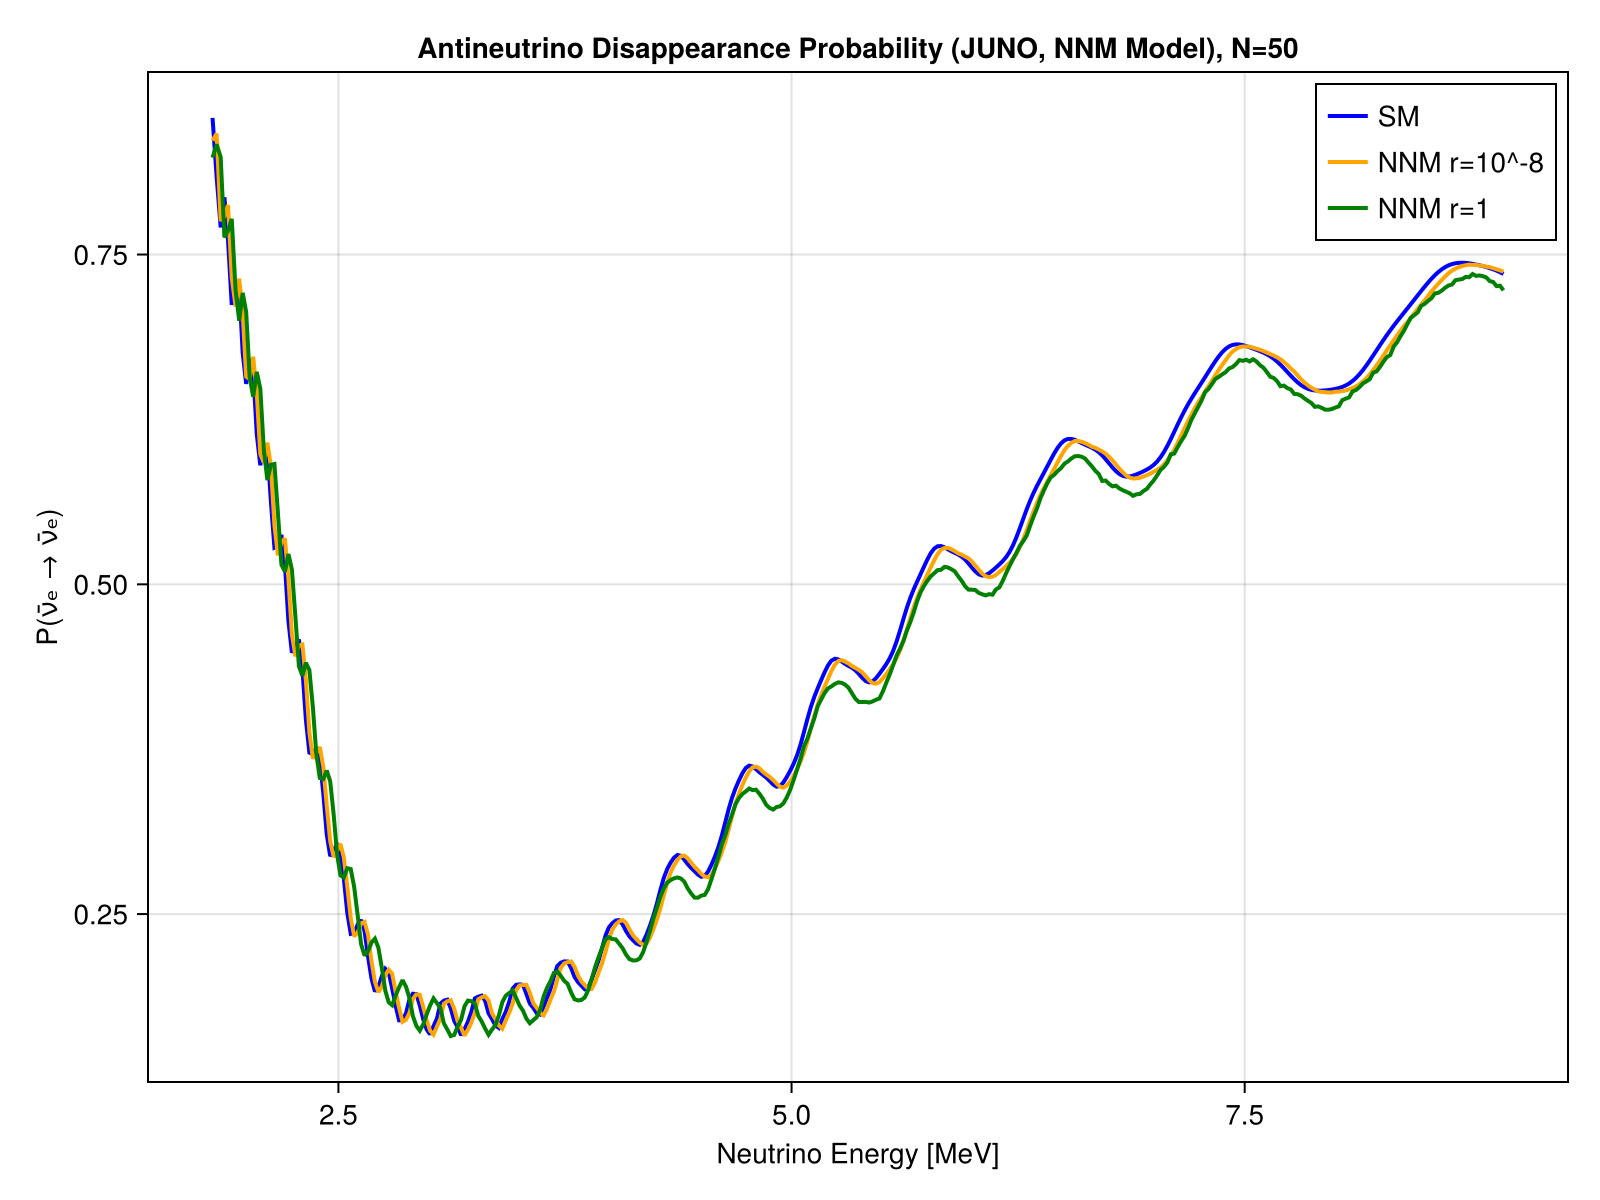

In [88]:

fig = Figure(size=(800, 600))
ax = Axis(fig[1, 1],
    xlabel="Neutrino Energy [MeV]",
    ylabel="P(ν̄ₑ → ν̄ₑ)",
    title="Antineutrino Disappearance Probability (JUNO, NNM Model), N=50"
 )

CairoMakie.lines!(ax, E_nu_SM, pro_SM.prob_weighted_flat, color=:blue, linewidth=2, label="SM")
CairoMakie.lines!(ax, E_nu_NNM, pro_NNM_lar.prob_weighted_flat, color=:orange, linewidth=2, label="NNM r=10^-8")
CairoMakie.lines!(ax, E_nu_NNM, pro_NNM.prob_weighted_flat, color=:green, linewidth=2, label="NNM r=1")

axislegend(ax)
display("image/png", fig)

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


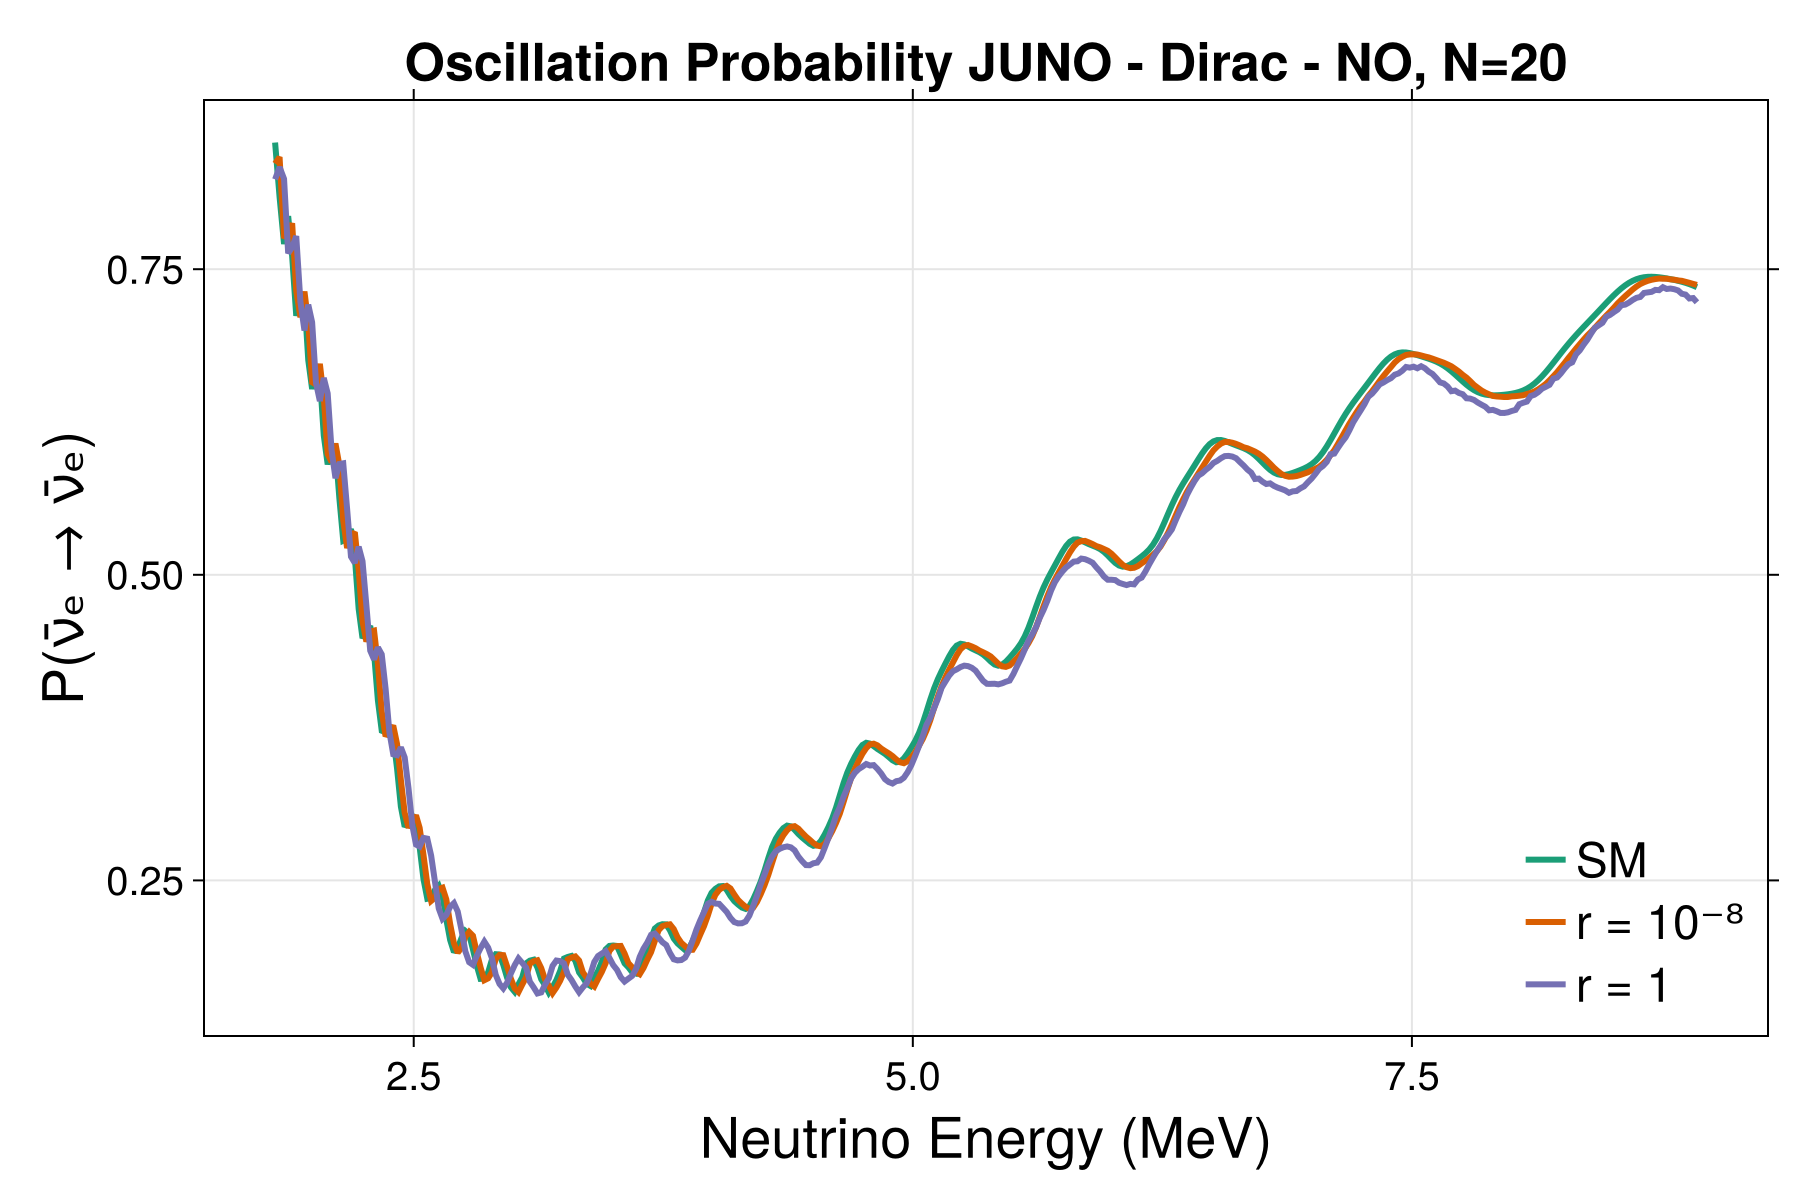

In [89]:
using CairoMakie
using ColorSchemes

palette = cgrad(:Dark2_8, categorical=true)

c_1 = palette[1]
c_2 = palette[2]
c_3 = palette[3]

fig = Figure(resolution=(900, 600))

ax = Axis(
    fig[1, 1],
    xlabel = "Neutrino Energy (MeV)",
    ylabel = "P(ν̄ₑ → ν̄ₑ)",
    title = "Oscillation Probability JUNO - Dirac - NO, N=20",
    xlabelsize=28,
    ylabelsize=28,
    titlesize=26,
    xticklabelsize=20,
    yticklabelsize=20,
    xgridvisible=true,
    ygridvisible=true,
    xgridcolor=:gray90,
    ygridcolor=:gray90,
    xticksmirrored=true,
    yticksmirrored=true
)

lines!(
    ax,
    E_nu_SM,
    pro_SM.prob_weighted_flat,
    color = c_1,
    linewidth = 3,
    label = "SM"
)

lines!(
    ax,
    E_nu_NNM,
    pro_NNM_lar.prob_weighted_flat,
    color = c_2,
    linewidth = 3,
    #linestyle = :dot,
    label = "r = 10⁻⁸"
)

lines!(
    ax,
    E_nu_NNM,
    pro_NNM.prob_weighted_flat,
    color = c_3,
    linewidth = 3,
    label = "r = 1"
)

axislegend(
    ax,
    position = :rb,
    labelsize = 24,
    framevisible = false
)

#xlims!(ax, minimum(E_nu_SM), maximum(E_nu_SM))

display("image/png", fig)

# Recommended for papers
#save("/home/sofialon/Newtrinos.jl/plots_svg/juno/juno_NND_NO_r.png", fig)
#save("/home/sofialon/Newtrinos.jl/plots_svg/juno/juno_NND_NO_r.svg", fig)

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


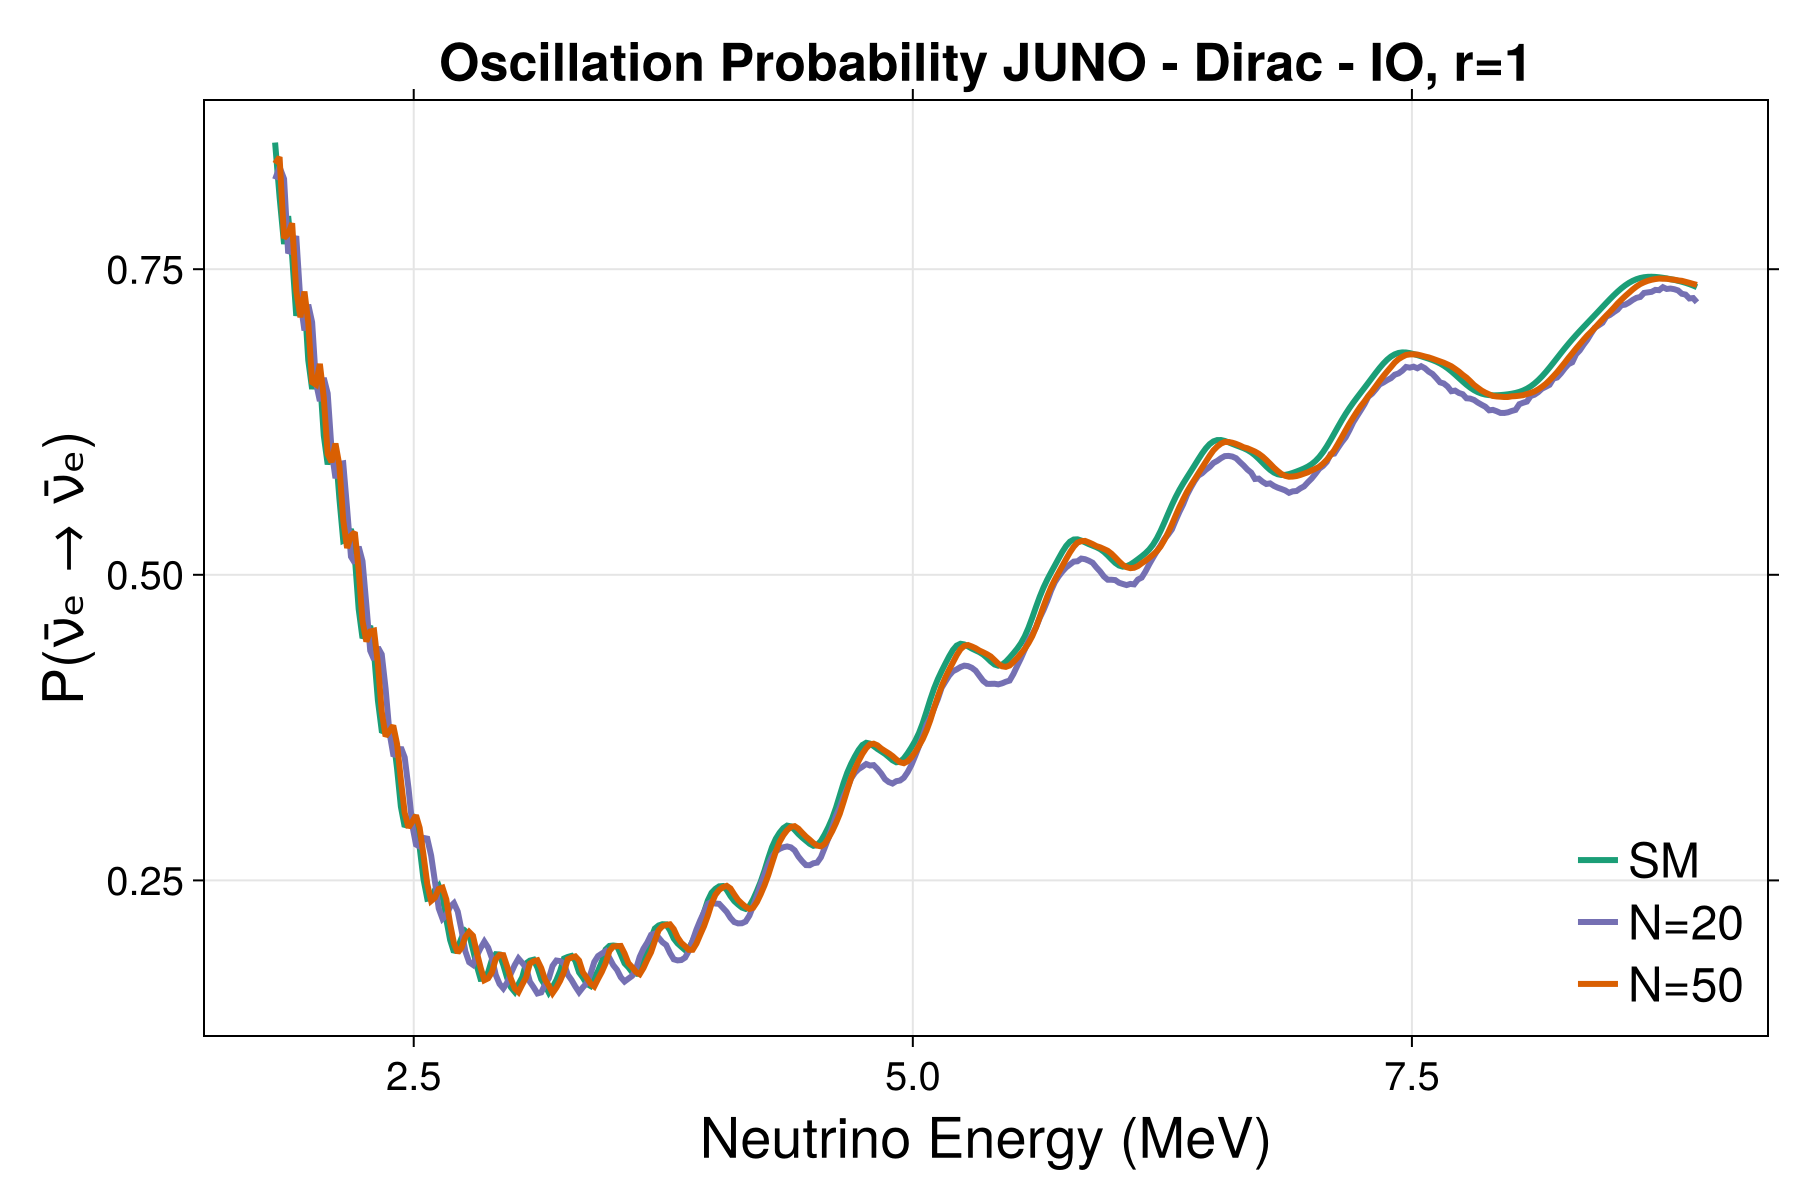

CairoMakie.Screen{SVG}


In [90]:
using CairoMakie
using ColorSchemes

palette = cgrad(:Dark2_8, categorical=true)

c_1 = palette[1]
c_2 = palette[2]
c_3 = palette[3]

fig = Figure(resolution=(900, 600))

ax = Axis(
    fig[1, 1],
    xlabel = "Neutrino Energy (MeV)",
    ylabel = "P(ν̄ₑ → ν̄ₑ)",
    title = "Oscillation Probability JUNO - Dirac - IO, r=1",
    xlabelsize=28,
    ylabelsize=28,
    titlesize=26,
    xticklabelsize=20,
    yticklabelsize=20,
    xgridvisible=true,
    ygridvisible=true,
    xgridcolor=:gray90,
    ygridcolor=:gray90,
    xticksmirrored=true,
    yticksmirrored=true
)

lines!(
    ax,
    E_nu_SM,
    pro_SM.prob_weighted_flat,
    color = c_1,
    linewidth = 3,
    label = "SM"
)
lines!(
    ax,
    E_nu_NNM,
    pro_NNM.prob_weighted_flat,
    color = c_3,
    linewidth = 3,
    label = "N=20"
)

lines!(
    ax,
    E_nu_NNM,
    pro_NNM_lar.prob_weighted_flat,
    color = c_2,
    linewidth = 3,
    #linestyle = :dot,
    label = "N=50"
)



axislegend(
    ax,
    position = :rb,
    labelsize = 24,
    framevisible = false
)

#xlims!(ax, minimum(E_nu_SM), maximum(E_nu_SM))

display("image/png", fig)

# Recommended for papers
save("/home/sofialon/Newtrinos.jl/plots_svg/juno/juno_NND_IO_N.png", fig)
save("/home/sofialon/Newtrinos.jl/plots_svg/juno/juno_NND_IO_N.svg", fig)

In [ ]:
scan_NNM = Newtrinos.scan(lik_NNM, pri_NNM, (N=30,  m₀=30), p_NNM)
pl_sc_NNM = CairoMakie.plot(scan_NNM)

In [ ]:
logL_NNM = logdensityof(lik_NNM, p_NNM)
println("Llh for NNM model: ", logL_NNM)

logL_SM = logdensityof(lik_SM, p_SM)  
println("Llh for SM model: ", logL_SM)

In [ ]:
llh_profile_1D_N = [maximum(scan_NNM.values.log_posterior[i, :]) for i in 1:size(scan_NNM.values.log_posterior, 1)]

q_values_1D = -2 * (llh_profile_1D_N .- maximum(llh_profile_1D_N))
println("Full q_values_1D: ", q_values_1D)

N_scan_points_1D = scan_NNM.axes.N

Plots.plot(N_scan_points_1D, q_values_1D, marker=:o, xlabel="N", ylabel="-2ΔLLH", title="")
Plots.hline!([2.71], label="90% CL (1 dof)", linestyle=:dash)
Plots.hline!([3.84], label="95% CL (1 dof)", linestyle=:dot)

In [ ]:
Plots.heatmap(scan_NNM.axes.N, scan_NNM.axes.m₀, scan_NNM.values.log_posterior, xlabel="N", ylabel="m₀", title="2D Log-Posterior", xscale=:log10)

In [ ]:
Plots.plot(scan_NNM.axes.m₀, scan_NNM.values.log_posterior[:, findmin(abs.(scan_NNM.axes.N .- 20))[2]], xlabel="m₀", ylabel="Log-Posterior", title="Slice at N = 20")

In [ ]:
idx_peak = findmin(abs.(scan_NNM.axes.N .- 15))[2]
idx_dip = findmin(abs.(scan_NNM.axes.N .- 25))[2]
p1 = Plots.plot(scan_NNM.axes.m₀, scan_NNM.values.log_posterior[idx_peak, :], xlabel="m₀ (eV)", ylabel="Log-Posterior", title="Slice at N = 15", label="Log-Posterior")
p2 = Plots.plot(scan_NNM.axes.m₀, scan_NNM.values.log_posterior[idx_dip, :], xlabel="m₀ (eV)", ylabel="Log-Posterior", title="Slice at N = 25", label="Log-Posterior")
Plots.plot(p1, p2, layout=(2,1))

In [ ]:
scan_NNM_larprio = Newtrinos.scan(lik_NNM, priors_NNM_new, (N=30,  m₀=30), p_NNM)
pl_NNM_larprio = CairoMakie.plot(scan_NNM_larprio)

In [ ]:
llh_profile_1D_N = [maximum(scan_NNM_larprio.values.log_posterior[i, :]) for i in 1:size(scan_NNM_larprio.values.log_posterior, 1)]

q_values_1D = -2 * (llh_profile_1D_N .- maximum(llh_profile_1D_N))
println("Full q_values_1D: ", q_values_1D)

N_scan_points_1D = scan_NNM_larprio.axes.N

Plots.plot(N_scan_points_1D, q_values_1D, marker=:o, xlabel="N", ylabel="-2ΔLLH", title="")
Plots.hline!([2.71], label="90% CL (1 dof)", linestyle=:dash)
Plots.hline!([3.84], label="95% CL (1 dof)", linestyle=:dot)